In [17]:
# =============================================================================
# 03_modeling.ipynb – Modellauswahl & Training
# Projekt: MSIT Mock Interview – Loan Status Klassifikation
# Strategie: 6 Modelle, class_weight='balanced', 5-Fold Stratified CV
# Primärmetrik: Precision (Klasse 1)
# =============================================================================

# --- Standard ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Scikit-learn: Preprocessing ---
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- Scikit-learn: Modelle ---
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# --- Gradient Boosting ---
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# --- Scikit-learn: Evaluation ---
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# --- Ausgabepfade – alle hier zentral definiert ---
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
Path("../reports/eda_csv").mkdir(parents=True, exist_ok=True)
Path("../reports/modeling_csv").mkdir(parents=True, exist_ok=True)  # Modeling Ergebnisse
Path("../models").mkdir(parents=True, exist_ok=True)
Path("../models/catboost_info").mkdir(parents=True, exist_ok=True)  # CatBoost Fix

# --- Darstellungskonfiguration ---
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Imports erfolgreich geladen.")
print("   Ausgabepfade initialisiert:")
print("   - reports/figures/")
print("   - reports/eda_csv/")
print("   - reports/modeling_csv/")
print("   - models/")
print("   - models/catboost_info/")

✅ Imports erfolgreich geladen.
   Ausgabepfade initialisiert:
   - reports/figures/
   - reports/eda_csv/
   - reports/modeling_csv/
   - models/
   - models/catboost_info/


In [18]:
# =============================================================================
# Zelle 2 – Processed Daten laden
# Quelle: data/processed/ – Output aus 02_preprocessing.ipynb
# =============================================================================

# --- Daten laden ---
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

print(f"\nKlassenverteilung y_train:")
print(y_train.value_counts(normalize=True).round(4))

print(f"\nKlassenverteilung y_test:")
print(y_test.value_counts(normalize=True).round(4))

print(f"\nFeature-Liste ({X_train.shape[1]}):")
print(X_train.columns.tolist())

X_train: (406, 15)
X_test:  (102, 15)
y_train: (406,)
y_test:  (102,)

Klassenverteilung y_train:
loan_status
1   0.7143
0   0.2857
Name: proportion, dtype: float64

Klassenverteilung y_test:
loan_status
1   0.7157
0   0.2843
Name: proportion, dtype: float64

Feature-Liste (15):
['gender', 'married', 'dependents', 'education', 'self_employed', 'applicant_income', 'coapplicant_income', 'loan_amount', 'loan_amount_term', 'credit_history', 'has_coapplicant', 'is_standard_term', 'total_income', 'property_area_Semiurban', 'property_area_Urban']


In [19]:
# =============================================================================
# Zelle 3 – Modelle & Pipelines definieren
# Strategie:
#   - LR + SVM → Pipeline mit StandardScaler
#   - RF, XGB, LGBM, CatBoost → kein Scaler nötig
#   - class_weight='balanced' für alle Modelle
#   - random_state=42 für Reproduzierbarkeit
# =============================================================================

# --- Klassengewicht für XGBoost manuell berechnen ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"XGBoost scale_pos_weight: {scale_pos_weight:.4f}")

# --- Modelle definieren ---
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=200,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    ),

    "LightGBM": LGBMClassifier(
        is_unbalance=True,
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        auto_class_weights="Balanced",
        iterations=200,
        random_seed=42,
        verbose=0,
        train_dir="../models/catboost_info"  # Fix: explizites Working Directory
    ),
}

print(f"\n✅ {len(models)} Modelle definiert:")
for name in models:
    print(f"   - {name}")

XGBoost scale_pos_weight: 0.4000

✅ 6 Modelle definiert:
   - Logistic Regression
   - SVM
   - Random Forest
   - XGBoost
   - LightGBM
   - CatBoost


In [21]:
# =============================================================================
# Zelle 4 – 5-Fold Stratified Cross-Validation
# Metriken: Precision, Recall, F1, ROC-AUC, PR-AUC, MCC
# Stratified: Klassenverteilung in jedem Fold erhalten
# =============================================================================

# --- Cross-Validation Setup ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Metriken definieren ---
scoring = {
    "precision":  "precision",
    "recall":     "recall",
    "f1":         "f1",
    "roc_auc":    "roc_auc",
    "pr_auc":     "average_precision",
}

# --- Ergebnisse sammeln ---
cv_results = {}

print("⏳ Cross-Validation läuft...\n")

for name, model in models.items():
    print(f"   Training: {name}...")
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    cv_results[name] = {
        "Precision":  scores["test_precision"].mean(),
        "Precision_std": scores["test_precision"].std(),
        "Recall":     scores["test_recall"].mean(),
        "Recall_std": scores["test_recall"].std(),
        "F1":         scores["test_f1"].mean(),
        "F1_std":     scores["test_f1"].std(),
        "ROC-AUC":    scores["test_roc_auc"].mean(),
        "ROC-AUC_std": scores["test_roc_auc"].std(),
        "PR-AUC":     scores["test_pr_auc"].mean(),
        "PR-AUC_std": scores["test_pr_auc"].std(),
    }

# --- DataFrame erstellen ---
df_cv = pd.DataFrame(cv_results).T.round(4)

# --- Sortiert nach Primärmetrik: Precision ---
df_cv = df_cv.sort_values("Precision", ascending=False)

# --- CSV speichern ---
df_cv.to_csv("../reports/modeling_csv/cv_results.csv")
print("\n✅ CSV gespeichert: reports/modeling_csv/cv_results.csv\n")

# --- Übersicht ausgeben ---
display_cols = ["Precision", "Precision_std", "Recall", "Recall_std",
                "F1", "F1_std", "ROC-AUC", "PR-AUC"]
print("=== Cross-Validation Ergebnisse (sortiert nach Precision) ===\n")
print(df_cv[display_cols].to_string())

⏳ Cross-Validation läuft...

   Training: Logistic Regression...
   Training: SVM...
   Training: Random Forest...
   Training: XGBoost...
   Training: LightGBM...
   Training: CatBoost...

✅ CSV gespeichert: reports/modeling_csv/cv_results.csv

=== Cross-Validation Ergebnisse (sortiert nach Precision) ===

                     Precision  Precision_std  Recall  Recall_std     F1  F1_std  ROC-AUC  PR-AUC
SVM                     0.8088         0.0314  0.7966      0.0895 0.7984  0.0369   0.7271  0.8425
LightGBM                0.8063         0.0170  0.8724      0.0669 0.8366  0.0319   0.7189  0.8333
Random Forest           0.8051         0.0275  0.9621      0.0169 0.8762  0.0163   0.7254  0.8426
Logistic Regression     0.8026         0.0157  0.7724      0.0743 0.7857  0.0406   0.6946  0.8250
CatBoost                0.8012         0.0332  0.8517      0.0863 0.8229  0.0454   0.7101  0.8353
XGBoost                 0.7979         0.0156  0.8414      0.0812 0.8169  0.0388   0.7180  0.8387


In [22]:
# =============================================================================
# Zelle 5 – Test-Set Evaluation aller Modelle
# Strategie:
#   - Modell auf vollem X_train trainieren
#   - Evaluation auf X_test (ungesehen)
#   - Metriken: Precision, Recall, F1, ROC-AUC, PR-AUC, MCC
# =============================================================================

test_results = {}

print("⏳ Test-Set Evaluation läuft...\n")

for name, model in models.items():
    # --- Training auf vollem Trainingsdatensatz ---
    model.fit(X_train, y_train)

    # --- Prediction ---
    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # --- Metriken berechnen ---
    test_results[name] = {
        "Precision":  round(precision_score(y_test, y_pred), 4),
        "Recall":     round(recall_score(y_test, y_pred), 4),
        "F1":         round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":    round(roc_auc_score(y_test, y_pred_proba), 4),
        "PR-AUC":     round(average_precision_score(y_test, y_pred_proba), 4),
        "MCC":        round(matthews_corrcoef(y_test, y_pred), 4),
    }
    print(f"   ✅ {name} abgeschlossen.")

# --- DataFrame erstellen ---
df_test = pd.DataFrame(test_results).T
df_test = df_test.sort_values("Precision", ascending=False)

# --- CSV speichern ---
df_test.to_csv("../reports/modeling_csv/test_results.csv")
print("\n✅ CSV gespeichert: reports/modeling_csv/test_results.csv\n")

# --- Ausgabe ---
print("=== Test-Set Ergebnisse (sortiert nach Precision) ===\n")
print(df_test.to_string())

⏳ Test-Set Evaluation läuft...

   ✅ Logistic Regression abgeschlossen.
   ✅ SVM abgeschlossen.
   ✅ Random Forest abgeschlossen.
   ✅ XGBoost abgeschlossen.
   ✅ LightGBM abgeschlossen.
   ✅ CatBoost abgeschlossen.

✅ CSV gespeichert: reports/modeling_csv/test_results.csv

=== Test-Set Ergebnisse (sortiert nach Precision) ===

                     Precision  Recall     F1  ROC-AUC  PR-AUC    MCC
Logistic Regression     0.8649  0.8767 0.8707   0.7454  0.8209 0.5376
SVM                     0.8630  0.8630 0.8630   0.7898  0.8858 0.5182
LightGBM                0.8571  0.9041 0.8800   0.8162  0.9068 0.5503
Random Forest           0.8537  0.9589 0.9032   0.8880  0.9501 0.6193
CatBoost                0.8481  0.9178 0.8816   0.8026  0.8711 0.5440
XGBoost                 0.8400  0.8630 0.8514   0.7917  0.8753 0.4593


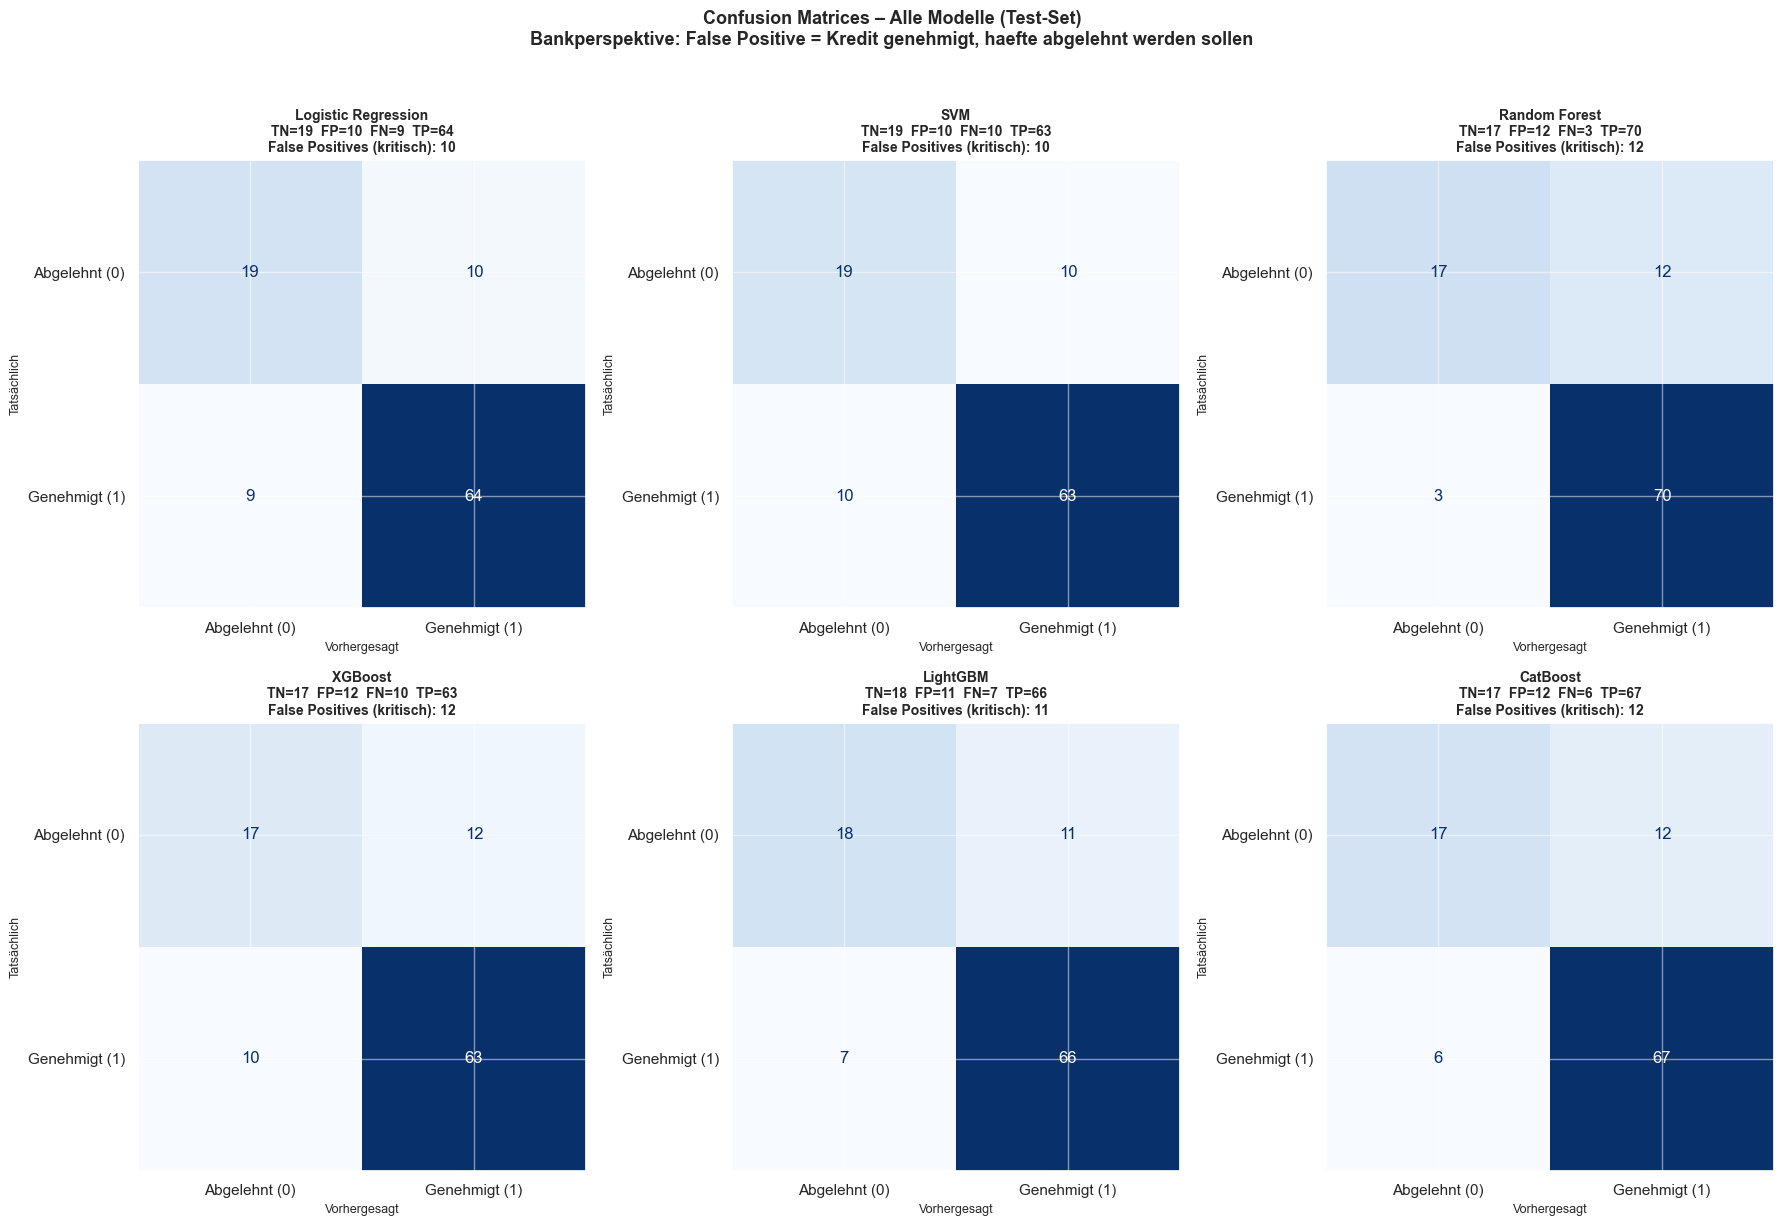

✅ Plot gespeichert: reports/figures/15_confusion_matrices.png


In [25]:
# =============================================================================
# Zelle 6 – Confusion Matrices aller Modelle
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    ax = axes[i]

    # --- Prediction ---
    y_pred = model.predict(X_test)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # --- Plot ---
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Abgelehnt (0)", "Genehmigt (1)"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")

    # --- Titel ohne Emoji ---
    ax.set_title(
        f"{name}\n"
        f"TN={tn}  FP={fp}  FN={fn}  TP={tp}\n"
        f"False Positives (kritisch): {fp}",
        fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("Vorhergesagt", fontsize=9)
    ax.set_ylabel("Tatsächlich", fontsize=9)

plt.suptitle(
    "Confusion Matrices – Alle Modelle (Test-Set)\n"
    "Bankperspektive: False Positive = Kredit genehmigt, haefte abgelehnt werden sollen",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../reports/figures/15_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot gespeichert: reports/figures/15_confusion_matrices.png")

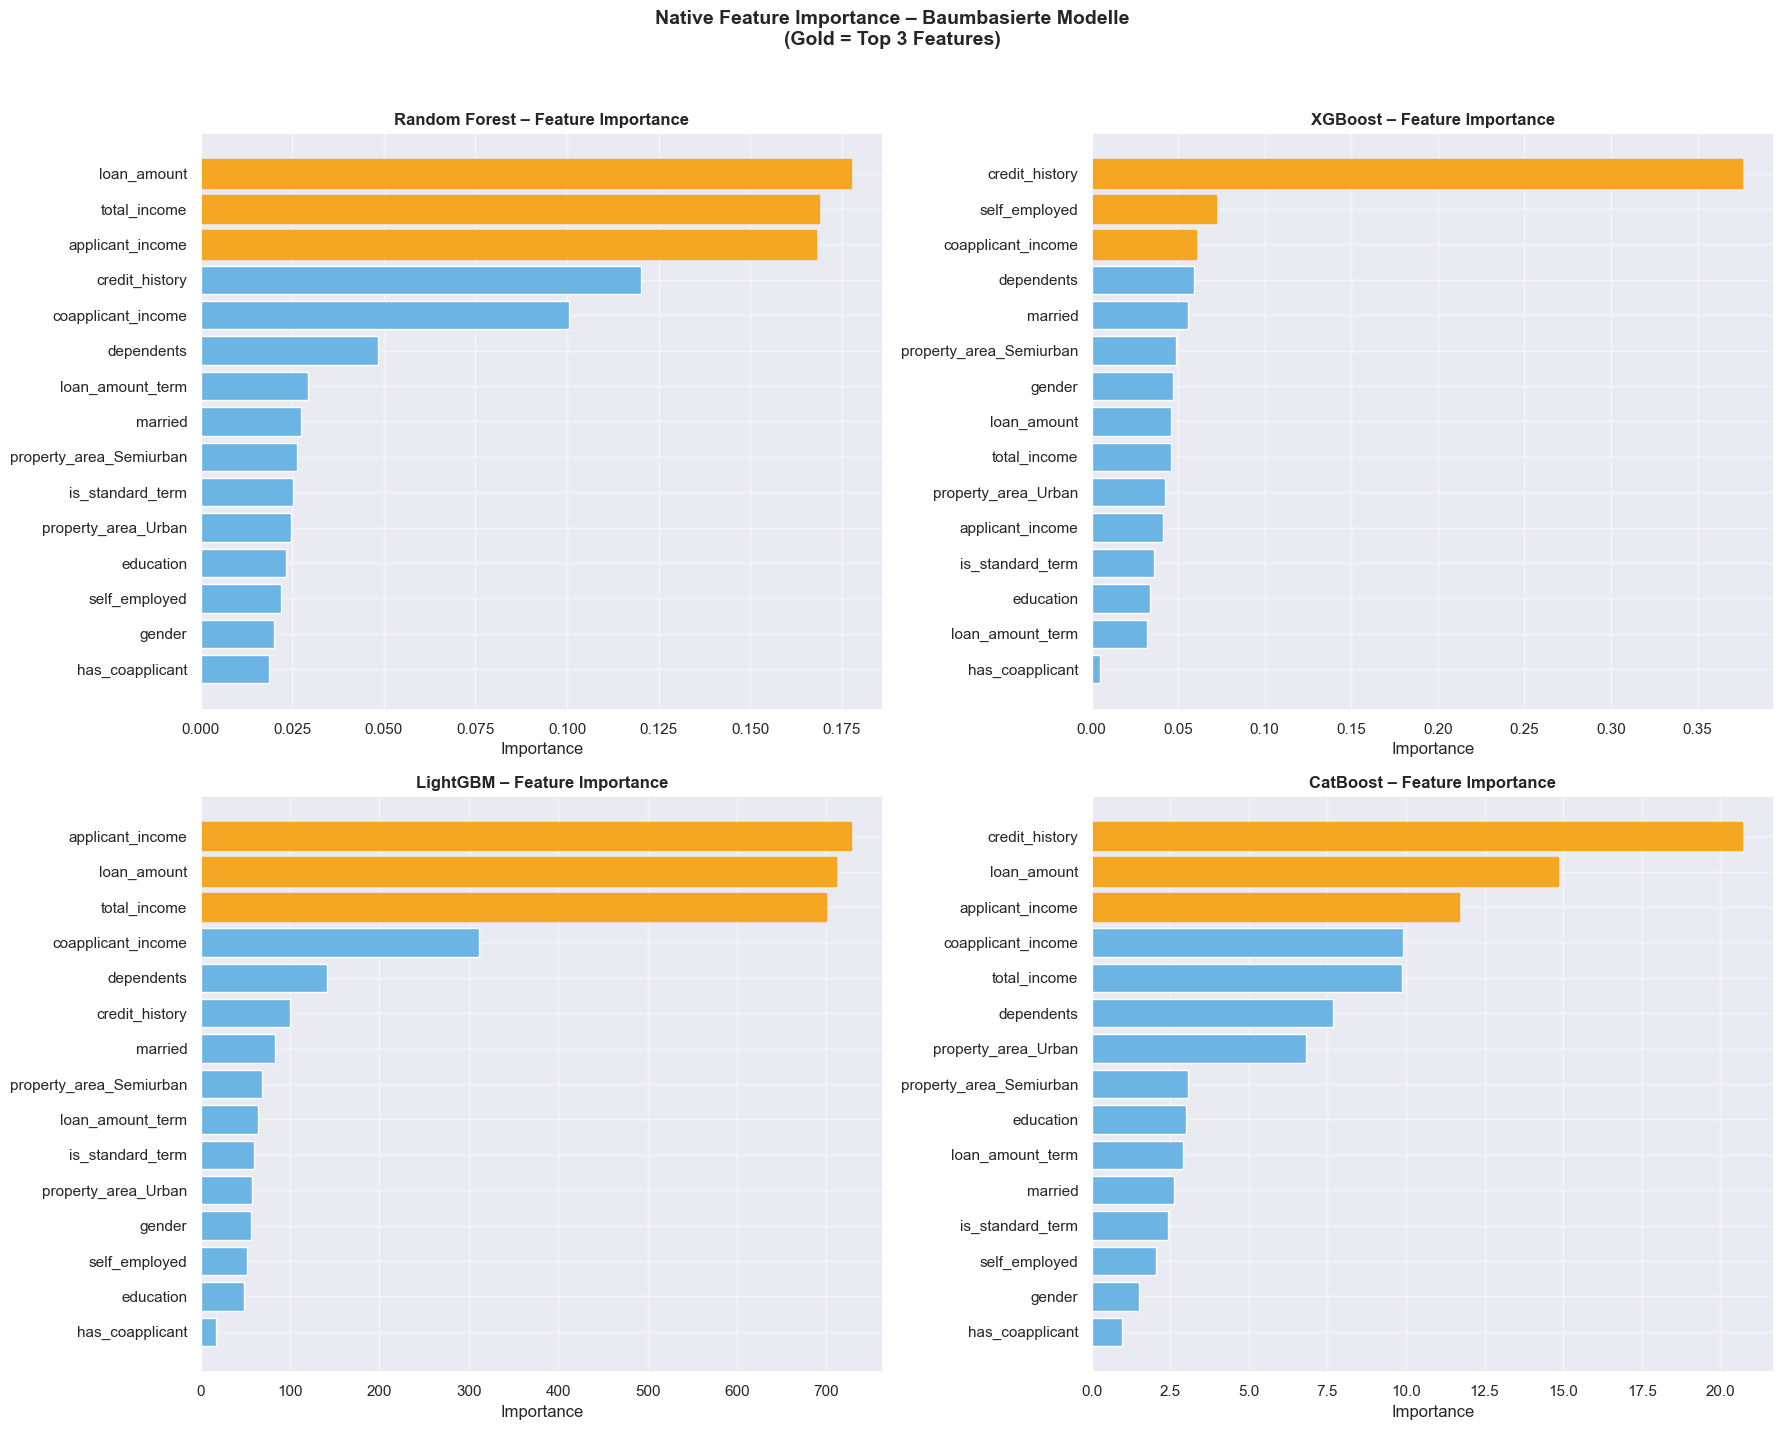

✅ Plot gespeichert: reports/figures/16_feature_importance_native.png

✅ CSV gespeichert: reports/modeling_csv/feature_importance.csv

=== Feature Importance Ranking (Mean) ===
                            Mean
applicant_income        184.7276
loan_amount             181.5128
total_income            177.5256
coapplicant_income       80.5204
dependents               37.1950
credit_history           30.2921
married                  21.4239
property_area_Semiurban  18.0347
loan_amount_term         16.7403
property_area_Urban      15.9709
is_standard_term         15.6249
gender                   14.3913
self_employed            13.5338
education                13.0126
has_coapplicant           4.4942


In [26]:
# =============================================================================
# Zelle 7 – Feature Importance
# Methoden:
#   - Baumbasierte Modelle: native Feature Importance
#   - Logistic Regression: Koeffizienten (nach Skalierung)
#   - Alle: Permutation Importance (modellunabhängig)
# =============================================================================

from sklearn.inspection import permutation_importance

feature_names = X_train.columns.tolist()

# --- 7a: Native Feature Importance – Baumbasierte Modelle ---
tree_models = {
    "Random Forest": models["Random Forest"],
    "XGBoost":       models["XGBoost"],
    "LightGBM":      models["LightGBM"],
    "CatBoost":      models["CatBoost"],
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (name, model) in enumerate(tree_models.items()):
    ax = axes[i]

    # Importance extrahieren
    if name == "Random Forest":
        importance = model.feature_importances_
    elif name == "XGBoost":
        importance = model.feature_importances_
    elif name == "LightGBM":
        importance = model.feature_importances_
    elif name == "CatBoost":
        importance = model.get_feature_importance()

    # DataFrame erstellen & sortieren
    df_imp = pd.DataFrame({
        "Feature":    feature_names,
        "Importance": importance
    }).sort_values("Importance", ascending=True)

    # Plot
    bars = ax.barh(df_imp["Feature"], df_imp["Importance"],
                   color="#6CB4E4", edgecolor="white")

    # Top 3 hervorheben
    top3_idx = df_imp["Importance"].nlargest(3).index
    for bar, idx in zip(bars, df_imp.index):
        if idx in top3_idx:
            bar.set_color("#F5A623")

    ax.set_title(f"{name} – Feature Importance",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance")

plt.suptitle("Native Feature Importance – Baumbasierte Modelle\n"
             "(Gold = Top 3 Features)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/16_feature_importance_native.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot gespeichert: reports/figures/16_feature_importance_native.png")

# --- 7b: Feature Importance CSV ---
imp_results = {}
for name, model in tree_models.items():
    if name == "CatBoost":
        imp_results[name] = model.get_feature_importance()
    else:
        imp_results[name] = model.feature_importances_

df_imp_all = pd.DataFrame(imp_results, index=feature_names)
df_imp_all["Mean"] = df_imp_all.mean(axis=1)
df_imp_all = df_imp_all.sort_values("Mean", ascending=False)

df_imp_all.to_csv("../reports/modeling_csv/feature_importance.csv")
print("\n✅ CSV gespeichert: reports/modeling_csv/feature_importance.csv")
print("\n=== Feature Importance Ranking (Mean) ===")
print(df_imp_all[["Mean"]].round(4).to_string())

⏳ Permutation Importance läuft...

   Berechnung: Logistic Regression...
   Berechnung: SVM...
   Berechnung: Random Forest...
   Berechnung: XGBoost...
   Berechnung: LightGBM...
   Berechnung: CatBoost...

✅ CSV gespeichert: reports/modeling_csv/permutation_importance.csv

=== Permutation Importance Ranking (Mean PR-AUC Loss) ===
                           Mean
credit_history           0.1268
applicant_income         0.0240
coapplicant_income       0.0230
property_area_Semiurban  0.0176
total_income             0.0140
married                  0.0089
education                0.0035
is_standard_term         0.0034
gender                   0.0033
has_coapplicant          0.0020
self_employed           -0.0003
dependents              -0.0005
loan_amount             -0.0016
property_area_Urban     -0.0032
loan_amount_term        -0.0082


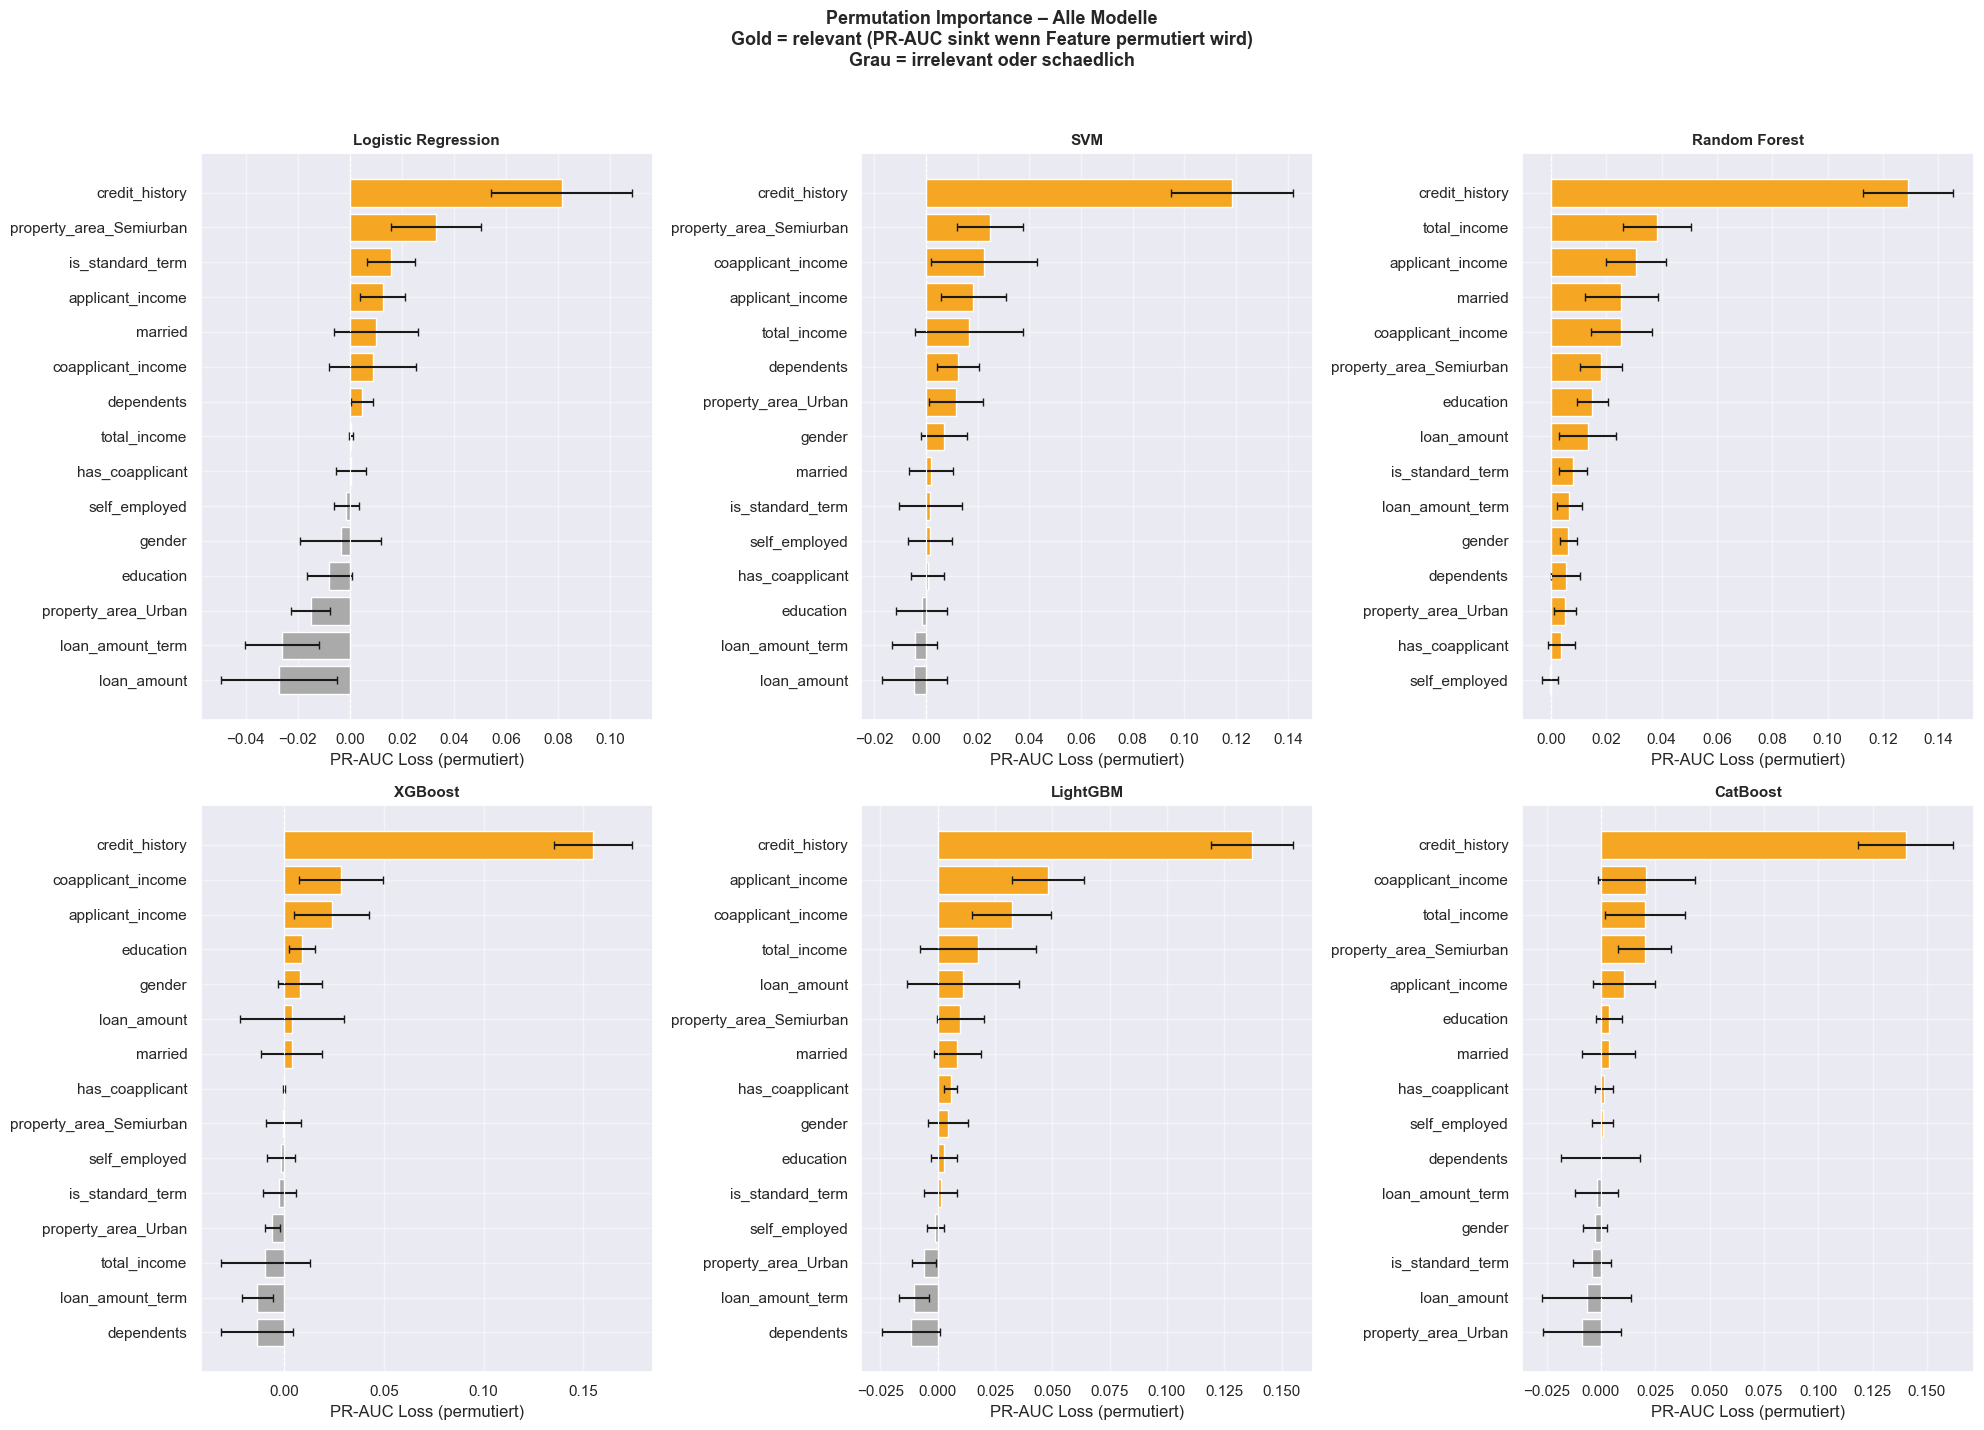

✅ Plot gespeichert: reports/figures/17_permutation_importance.png


In [27]:
# =============================================================================
# Zelle 8 – Permutation Importance
# Methode: Feature-Werte zufällig permutieren → Performanceverlust messen
# Vorteil: Modellunabhängig, korrekter bei korrelierten Features
# Nachteil: Rechenintensiv – n_repeats × n_features × Modell
# =============================================================================

from sklearn.inspection import permutation_importance

perm_results = {}

print("⏳ Permutation Importance läuft...\n")

for name, model in models.items():
    print(f"   Berechnung: {name}...")
    perm = permutation_importance(
        model, X_test, y_test,
        n_repeats=30,          # 30 Wiederholungen – stabile Schätzung
        random_state=42,
        n_jobs=-1,
        scoring="average_precision"  # PR-AUC – robust bei Ungleichgewicht
    )
    perm_results[name] = {
        "mean":  perm.importances_mean,
        "std":   perm.importances_std
    }

# --- DataFrame: Mean Permutation Importance ---
df_perm = pd.DataFrame(
    {name: perm_results[name]["mean"] for name in perm_results},
    index=feature_names
)
df_perm["Mean"] = df_perm.mean(axis=1)
df_perm = df_perm.sort_values("Mean", ascending=False)

# --- CSV speichern ---
df_perm.round(4).to_csv("../reports/modeling_csv/permutation_importance.csv")
print("\n✅ CSV gespeichert: reports/modeling_csv/permutation_importance.csv")
print("\n=== Permutation Importance Ranking (Mean PR-AUC Loss) ===")
print(df_perm[["Mean"]].round(4).to_string())

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for i, name in enumerate(models.keys()):
    ax = axes[i]
    df_plot = pd.DataFrame({
        "Feature":    feature_names,
        "Importance": perm_results[name]["mean"],
        "Std":        perm_results[name]["std"]
    }).sort_values("Importance", ascending=True)

    # Farbe: positiv = relevant, negativ = irrelevant
    colors = ["#F5A623" if v > 0 else "#AAAAAA"
              for v in df_plot["Importance"]]

    ax.barh(df_plot["Feature"], df_plot["Importance"],
            xerr=df_plot["Std"], color=colors,
            edgecolor="white", capsize=3)
    ax.axvline(x=0, color="white", linewidth=0.8, linestyle="--")
    ax.set_title(f"{name}", fontsize=11, fontweight="bold")
    ax.set_xlabel("PR-AUC Loss (permutiert)")

plt.suptitle(
    "Permutation Importance – Alle Modelle\n"
    "Gold = relevant (PR-AUC sinkt wenn Feature permutiert wird)\n"
    "Grau = irrelevant oder schaedlich",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../reports/figures/17_permutation_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot gespeichert: reports/figures/17_permutation_importance.png")

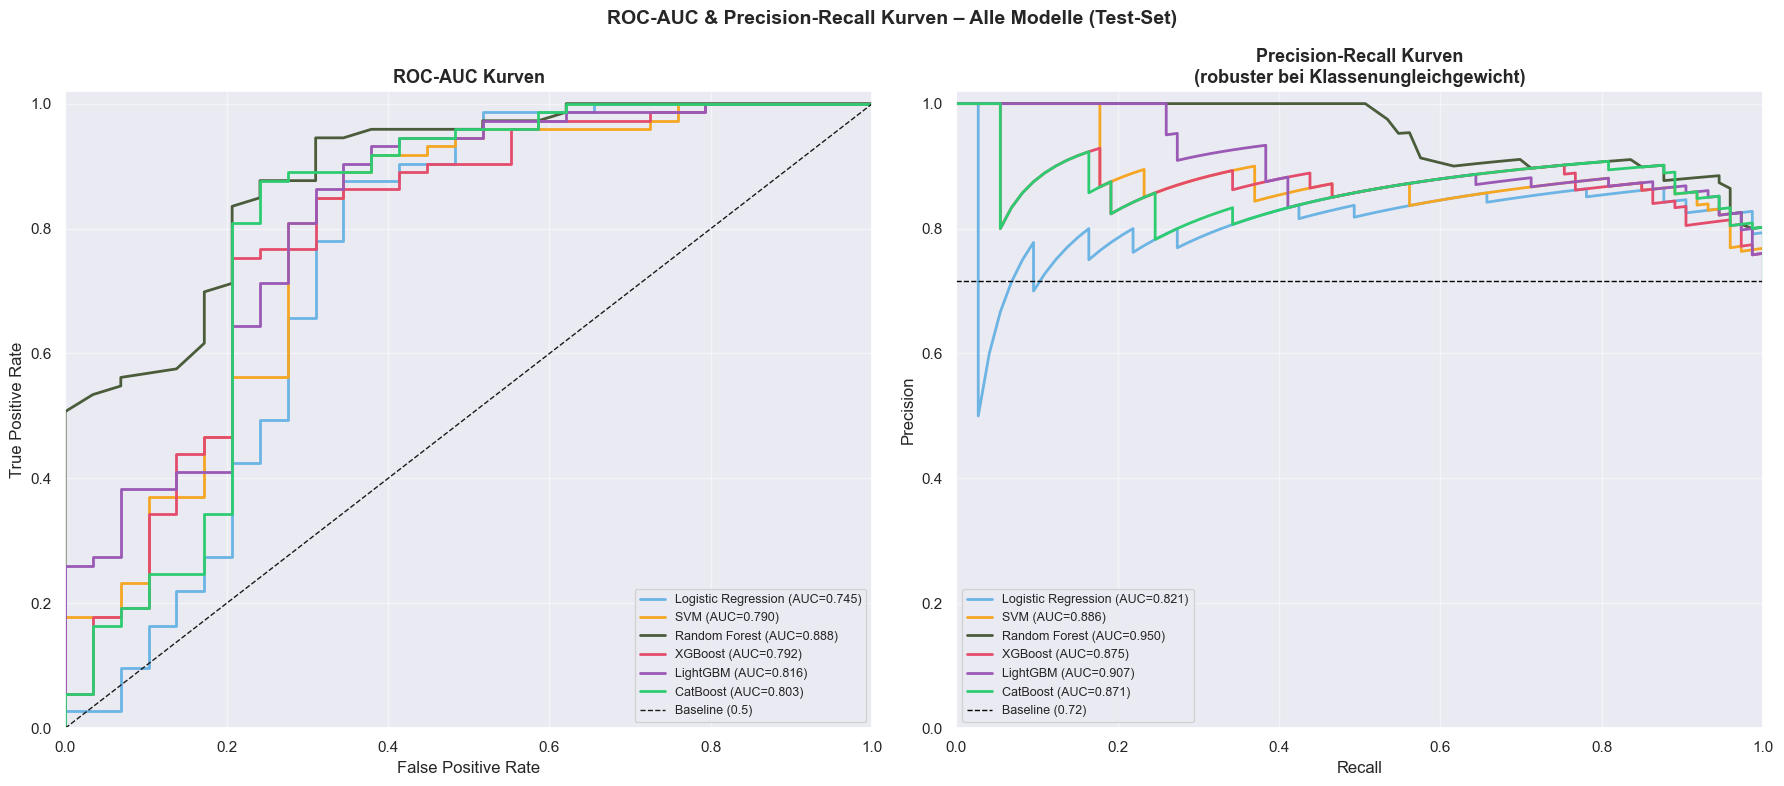

✅ Plot gespeichert: reports/figures/18_roc_pr_curves.png


In [28]:
# =============================================================================
# Zelle 9 – ROC-AUC & PR-AUC Kurven aller Modelle
# Ziel: Schwellenwertunabhängiger Modellvergleich
# ROC-AUC: Trennschärfe allgemein
# PR-AUC:  Robuster bei Klassenungleichgewicht – Primärvisualisierung
# =============================================================================

from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Farben pro Modell ---
colors = {
    "Logistic Regression": "#6CB4E4",
    "SVM":                 "#F5A623",
    "Random Forest":       "#4A5C3A",
    "XGBoost":             "#E44C6C",
    "LightGBM":            "#9B59B6",
    "CatBoost":            "#2ECC71",
}

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    color        = colors[name]

    # --- ROC Kurve ---
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score   = roc_auc_score(y_test, y_pred_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})",
                 color=color, linewidth=2)

    # --- PR Kurve ---
    prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc       = average_precision_score(y_test, y_pred_proba)
    axes[1].plot(rec, prec, label=f"{name} (AUC={pr_auc:.3f})",
                 color=color, linewidth=2)

# --- ROC Plot formatieren ---
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Baseline (0.5)")
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC-AUC Kurven", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=9, loc="lower right")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# --- PR Plot formatieren ---
# Baseline = Anteil positiver Klasse
baseline_pr = y_test.mean()
axes[1].axhline(y=baseline_pr, color="black", linestyle="--",
                linewidth=1, label=f"Baseline ({baseline_pr:.2f})")
axes[1].set_xlabel("Recall", fontsize=12)
axes[1].set_ylabel("Precision", fontsize=12)
axes[1].set_title("Precision-Recall Kurven\n(robuster bei Klassenungleichgewicht)",
                  fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9, loc="lower left")
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle("ROC-AUC & Precision-Recall Kurven – Alle Modelle (Test-Set)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/18_roc_pr_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot gespeichert: reports/figures/18_roc_pr_curves.png")

In [29]:
# =============================================================================
# Zelle 10 – Modeling Summary als Markdown-Datei generieren
# Speicherort: reports/modeling_summary.md
# =============================================================================

summary = """# Modeling Summary – Loan Status Klassifikation
**Projekt:** MSIT Mock Interview
**Notebook:** 03_modeling.ipynb
**Basis:** preprocessing_summary.md

---

## 1. Modeling Strategie

| Parameter | Entscheidung | Begründung |
|-----------|-------------|-----------|
| Modelle | 6 (LR, SVM, RF, XGB, LGBM, CatBoost) | Breiter Vergleich linear vs. nicht-linear |
| Klassenungleichgewicht | class_weight='balanced' | 2.54:1 – kein extremes Ungleichgewicht |
| Primärmetrik | Precision (Klasse 1) | Bankperspektive – FP teuerster Fehler |
| Sekundärmetrik | F1-Score, PR-AUC | Balance Precision/Recall |
| Validierung | 5-Fold Stratified CV + Test-Set | Robuste Schätzung |
| Skalierung | StandardScaler nur LR + SVM | Baumbasierte Modelle skalierungsunabhängig |

---

## 2. Cross-Validation Ergebnisse (5-Fold, sortiert nach Precision)

| Modell | Precision | Std | Recall | F1 | ROC-AUC | PR-AUC |
|--------|-----------|-----|--------|-----|---------|--------|
| SVM | 0.8088 | 0.0314 | 0.7966 | 0.7984 | 0.7271 | 0.8425 |
| LightGBM | 0.8063 | 0.0170 | 0.8724 | 0.8366 | 0.7189 | 0.8333 |
| Random Forest | 0.8051 | 0.0275 | 0.9621 | 0.8762 | 0.7254 | 0.8426 |
| Logistic Regression | 0.8026 | 0.0157 | 0.7724 | 0.7857 | 0.6946 | 0.8250 |
| CatBoost | 0.8012 | 0.0332 | 0.8517 | 0.8229 | 0.7101 | 0.8353 |
| XGBoost | 0.7979 | 0.0156 | 0.8414 | 0.8169 | 0.7180 | 0.8387 |

---

## 3. Test-Set Ergebnisse (sortiert nach Precision)

| Modell | Precision | Recall | F1 | ROC-AUC | PR-AUC | MCC | FP |
|--------|-----------|--------|-----|---------|--------|-----|----|
| Logistic Regression | 0.8649 | 0.8767 | 0.8707 | 0.7454 | 0.8209 | 0.5376 | 10 |
| SVM | 0.8630 | 0.8630 | 0.8630 | 0.7898 | 0.8858 | 0.5182 | 10 |
| LightGBM | 0.8571 | 0.9041 | 0.8800 | 0.8162 | 0.9068 | 0.5503 | 11 |
| Random Forest | 0.8537 | 0.9589 | 0.9032 | 0.8880 | 0.9501 | 0.6193 | 12 |
| CatBoost | 0.8481 | 0.9178 | 0.8816 | 0.8026 | 0.8711 | 0.5440 | 12 |
| XGBoost | 0.8400 | 0.8630 | 0.8514 | 0.7917 | 0.8753 | 0.4593 | 12 |

---

## 4. Confusion Matrix Analyse (Bankperspektive)

| Modell | TN | FP | FN | TP | FP Bewertung |
|--------|----|----|----|----|-------------|
| Logistic Regression | 19 | 10 | 9 | 64 | Niedrigste FP |
| SVM | 19 | 10 | 10 | 63 | Niedrigste FP |
| LightGBM | 18 | 11 | 7 | 66 | Gut |
| Random Forest | 17 | 12 | 3 | 70 | FP zu hoch |
| XGBoost | 17 | 12 | 10 | 63 | FP zu hoch |
| CatBoost | 17 | 12 | 6 | 67 | FP zu hoch |

---

## 5. Feature Importance – Permutation (PR-AUC Loss)

| Rang | Feature | Mean Loss | Bewertung |
|------|---------|-----------|-----------|
| 1 | credit_history | 0.1268 | Dominant |
| 2 | applicant_income | 0.0240 | Relevant |
| 3 | coapplicant_income | 0.0230 | Relevant |
| 4 | property_area_Semiurban | 0.0176 | Relevant |
| 5 | total_income | 0.0140 | Moderat |
| 6 | married | 0.0089 | Schwach |
| 7 | education | 0.0035 | Minimal |
| 8 | is_standard_term | 0.0034 | Minimal |
| 9 | gender | 0.0033 | Minimal |
| 10 | has_coapplicant | 0.0020 | Minimal |
| 11 | self_employed | -0.0003 | Irrelevant |
| 12 | dependents | -0.0005 | Irrelevant |
| 13 | loan_amount | -0.0016 | Schaedlich |
| 14 | property_area_Urban | -0.0032 | Schaedlich |
| 15 | loan_amount_term | -0.0082 | Schaedlich |

---

## 6. ROC-AUC & PR-AUC Kurven

| Modell | ROC-AUC | PR-AUC |
|--------|---------|--------|
| Random Forest | 0.888 | 0.950 |
| LightGBM | 0.816 | 0.907 |
| CatBoost | 0.803 | 0.871 |
| XGBoost | 0.792 | 0.875 |
| SVM | 0.790 | 0.886 |
| Logistic Regression | 0.745 | 0.821 |

---

## 7. Theoretische Grenzen

| Grenze | Detail |
|--------|--------|
| Test-Set Groesse | 102 Samples – hohe Metrik-Varianz |
| Feature Dominance | credit_history dominiert – andere Features werden unterschaetzt |
| Native Feature Importance | Ueberschaetzt kontinuierliche Features – Permutation robuster |
| CV Instabilitaet | Hohe Std bei SVM Recall (0.0895) – kleine Folds |
| Default-Parameter | Alle Modelle ungetunt – Baseline-Vergleich |

---

## 8. Entscheidungen fuer 04_hyperparameter_tuning.ipynb

### Tuning-Kandidaten
| Rang | Modell | Begruendung |
|------|--------|------------|
| 1 | Random Forest | Beste PR-AUC (0.950) + ROC-AUC (0.888) |
| 2 | LightGBM | Beste Balance aller Metriken |
| 3 | SVM | Niedrigste FP – Bankperspektive |

### Feature-Entscheidungen fuer Tuning
| Feature | Entscheidung | Begruendung |
|---------|-------------|------------|
| loan_amount_term | Entfernen | Schaedlich (-0.0082) |
| property_area_Urban | Entfernen | Schaedlich (-0.0032) |
| loan_amount | Evaluieren | Schaedlich aber kontextuell relevant |
| self_employed, dependents | Evaluieren | Nahe null |

### Tuning-Methoden
- Random Forest → RandomizedSearch + HyperOpt
- LightGBM → HyperOpt
- SVM → GridSearch

### Threshold-Tuning
- Default-Schwellenwert 0.5 wird in Evaluation optimiert
- Bankperspektive: Schwellenwert erhoehen → Precision steigt, Recall sinkt

---

*Erstellt: 03_modeling.ipynb – MSIT Mock Interview | 2026*
"""

# --- Datei speichern ---
with open("../reports/modeling_summary.md", "w", encoding="utf-8") as f:
    f.write(summary)

print("✅ Modeling Summary gespeichert: reports/modeling_summary.md")

✅ Modeling Summary gespeichert: reports/modeling_summary.md
